In [1]:
import sys, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

2026-01-10 19:02:11.972329: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()
print(f"Data shape: {data.shape}")
print(f"Labels shape (before one-hot): {labels.shape}")

Loaded cached data from ../../data/processed/melspec_cache.npz
Data shape: (14975, 150, 150, 1)
Labels shape (before one-hot): (14975,)


In [3]:
labels = mgr.one_hot()
print(f"Labels shape (one-hot): {labels.shape}")

Labels shape (one-hot): (14975, 10)


In [4]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (11980, 150, 150, 1)
X_test shape: (2995, 150, 150, 1)
Y_train shape: (11980, 10)
Y_test shape: (2995, 10)


In [5]:
CNN_1 = tf.keras.models.load_model('../models/CNN_1.keras')

I0000 00:00:1768068247.527499    9074 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
/mnt/c/Studia/Sem_5/Projektowe/GenreAI/.venv-wsl/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2026-01-10 19:04:19.859202: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f4d80027680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-10 19:04:19.859272: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-01-10 19:04:20.706130: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-10 19:04:22.088972: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


27/94 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

I0000 00:00:1768068274.231058    9572 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step


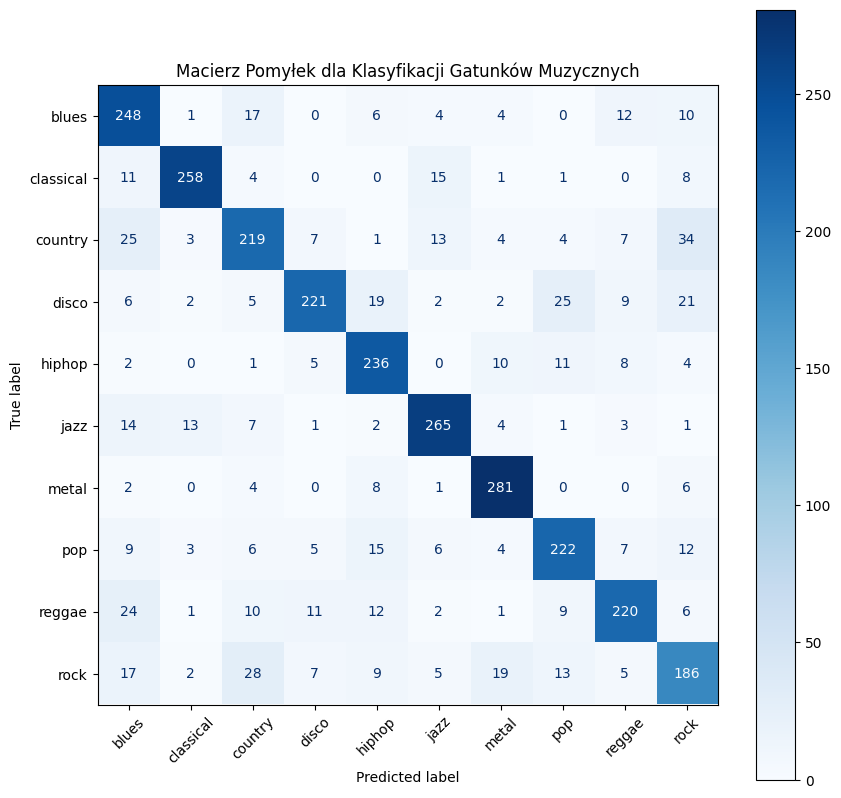

: 

In [ ]:
Y_pred_proba = CNN_1.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Macierz Pomyłek dla Klasyfikacji Gatunków Muzycznych')
plt.xticks(rotation=45)
plt.show()